# Customer Churn Prediction — Telecom Services

Predicting which telecom customers are likely to cancel their subscription (churn), so the business can step in early with a attractive offers.

## Section 1: Problem & Context

**Why churn matters.** Nowadays most of telecom companies are subscription based and making money so losing a customer isn't just one lost sale it’s about losing their all future payments It's also well known in the industry that it acquire a lot of cost and difficult to get a new customer than an existing customer. So if we can identify customers who are *about to* leave so the retention team can reach out to them with a discounts, offers something more on their current plan or just a support call before they cancel.

**How ML helps.** Instead of waiting for customers to churn we train a model on our previous customer data on people who already churned or stayed to find patterns like which contract types, tenure lengths, or add-on services are reasons why customers moving to other company. Then we use that model to calculate current customers and rank them by churn risk.

**About the data.** We're using the Telco Customer Churn dataset from Kaggle:

https://www.kaggle.com/datasets/blastchar/telco-customer-churn

This is a view of customer’s accounts from a fake telecom company. Each row is one customer with columns describing their demographics (gender, senior citizen status), account info (tenure, contract type, payment method) the services signed up for phone, internet, streaming, tech support, etc and their charges. The target column is Churn which is Yes if the customer left in the last month and No. if they're still a customer. For modelling we'll convert this to 1 (churned) and 0 means stayed.

**The ML task** This is a binary classification problem for each customer predict `Churn = 1` or `Churn = 0`, and ideally also get a probability score so we can rank customers by risk instead of just yes/no.

## Section 2: Data Exploration & Quality Analysis (EDA)

Before I do anything else I want to just look at the data. How many rows and columns, what type each column is, and if something looks broken like missing values.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Dataset from: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
df = pd.read_csv("file.csv")

print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# check datatypes and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

One thing I noticed is `TotalCharges` is showing text not as number. That's weird because it should just be dollars. then I check for missing values in the normal way first and then find out why this column is not numeric.

In [ ]:

print(df.isnull().sum().sum(), "missing values found by isnull()")

# TotalCharges is text, so maybe some rows are just empty spaces instead of a real NaN
blank_mask = df["TotalCharges"].str.strip() == ""
print("rows where TotalCharges is just blank:", blank_mask.sum())
df[blank_mask][["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

0 missing values found by isnull()
rows where TotalCharges is just blank: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


So `isnull()` said 0 missing, but that's only because these 11 rows have a blank string `" "` instead of an actual NaN, so pandas doesn't count it as missing. All 11 of them have `tenure = 0`, which makes sense to me — they are brand new customers, first month, so there is no total charge yet. I will fix this properly in Section 3. For now I'm just noting it as a data quality problem.

Next let me check the target column itself.

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


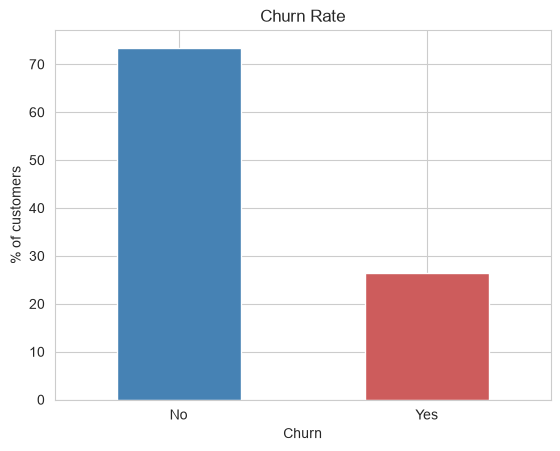

In [4]:
# how many customers churned vs stayed, in percent
churn_counts = df["Churn"].value_counts(normalize=True) * 100
print(churn_counts)

churn_counts.plot(kind="bar", color=["steelblue", "indianred"])
plt.title("Churn Rate")
plt.ylabel("% of customers")
plt.xticks(rotation=0)
plt.show()

Around 26% of customers churned and 74% stayed. Not a crazy imbalance but still enough that I need to be careful with it.

If I just predicted "No churn" for literally every customer I would already get about 74% accuracy, but that model would be completely useless since it would never actually catch anyone who is about to leave. So accuracy by itself is not a good metric here, it hides how bad the model might be at finding the smaller class, which is the one we actually care about.

Because of that I'm going to pay more attention to recall (out of the people who actually churned, how many did the model catch, since missing a churner means we lose them for good), precision (out of the people the model flagged as risky, how many actually churned, since sending out discounts costs money and we don't want to waste them on people who were never leaving anyway), and ROC-AUC as a more general score of how well the model tells churners and non-churners apart.

I'll come back to the precision vs recall thing again in Section 5.

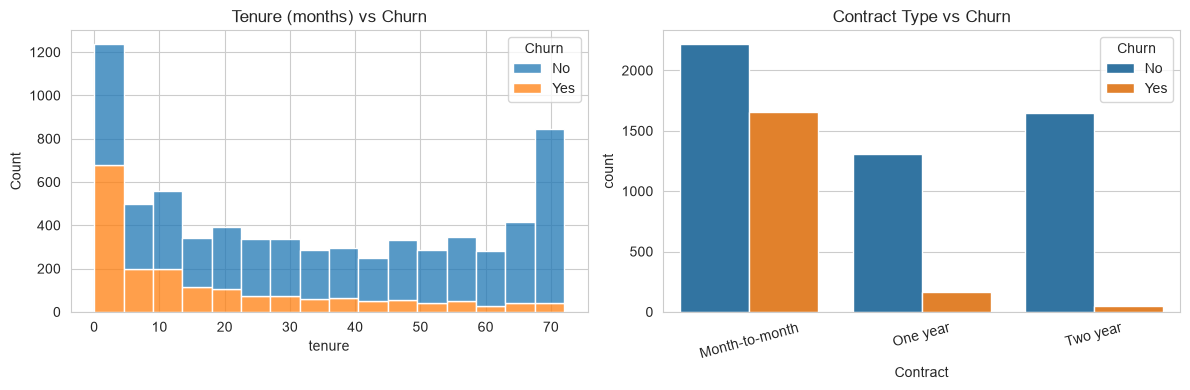

In [5]:
# quick look at tenure and contract type against churn
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack", ax=axes[0])
axes[0].set_title("Tenure (months) vs Churn")

sns.countplot(data=df, x="Contract", hue="Churn", ax=axes[1])
axes[1].set_title("Contract Type vs Churn")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

Two things stand out to me here. First, a lot of the churn happens in the first few months, once someone sticks around for a year or two they seem a lot less likely to leave. Second, month-to-month customers churn way more than the ones on 1-year or 2-year contracts, which kind of makes sense since a monthly plan costs nothing to cancel while a 2-year contract locks you in more.

So `tenure` and `Contract` already look like important features, I'll keep that in mind when I check feature importance later on.

## Section 3: Preprocessing & Feature Engineering

Now I need to actually fix the problems I found and get the data ready for a model. So here's what I'm doing: fix `TotalCharges`, drop the ID column since it's not useful for predicting anything, add 2 new features, turn the categories into numbers, scale the numeric columns, and then split into train and test.

In [6]:
data = df.copy()

# turn the blank strings into NaN, then convert to number, then just fill with 0
# (these are the tenure=0 people, so 0 total charge makes sense anyway)
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"].str.strip(), errors="coerce")
data["TotalCharges"] = data["TotalCharges"].fillna(0)

# customerID is just a label, not useful for the model
data = data.drop(columns=["customerID"])

# turn target into 0/1 so the model can use it
data["Churn"] = (data["Churn"] == "Yes").astype(int)

print("missing values left:", data.isnull().sum().sum())
data[["tenure", "TotalCharges", "MonthlyCharges", "Churn"]].head()

missing values left: 0


,tenure,TotalCharges,MonthlyCharges,Churn
0,1,29.85,29.85,0
1,34,1889.50,56.95,0
2,2,108.15,53.85,1
3,45,1840.75,42.30,0
4,2,151.65,70.70,1


### Making 2 new features

I want to add two small features before training anything.

First, `tenure_group`, which just puts tenure (months) into yearly buckets. I noticed in Section 2 that new customers churn a lot more, so putting tenure into year buckets should make that pattern more obvious to the model, especially for Logistic Regression.

Second, `total_services`, which counts how many of the extra services (OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies) a customer actually turned on. My guess is customers with more add-ons feel more locked in and churn less.

In [7]:
# 1. group tenure (months) into years
bins = [0, 12, 24, 36, 48, 60, 72]
labels = ["0-1yr", "1-2yr", "2-3yr", "3-4yr", "4-5yr", "5-6yr"]
data["tenure_group"] = pd.cut(data["tenure"], bins=bins, labels=labels, include_lowest=True)

# 2. count how many add-on services are turned on ("Yes")
addon_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
              "TechSupport", "StreamingTV", "StreamingMovies"]
data["total_services"] = (data[addon_cols] == "Yes").sum(axis=1)

data[["tenure", "tenure_group", "total_services"]].head()

,tenure,tenure_group,total_services
0,1,0-1yr,1
1,34,2-3yr,2
2,2,0-1yr,2
3,45,3-4yr,3
4,2,0-1yr,0


### Turning categories into numbers, scaling, and splitting

Models only understand numbers, so all the text columns (`Contract`, `PaymentMethod`, `InternetService`, my new `tenure_group`, etc.) need to become dummy 0/1 columns. The numeric columns (`tenure`, `MonthlyCharges`, `TotalCharges`, `total_services`) get scaled with `StandardScaler` so one big-range column doesn't dominate the others, mainly for Logistic Regression.

One thing I learned that's easy to mess up: I split into train/test **before** scaling, and I only fit the scaler on the training data. If I scaled everything first and then split, the test set would leak into the training process through the mean/std used for scaling.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# turn all text/category columns into dummy 0/1 columns
data_encoded = pd.get_dummies(data, drop_first=True)

X = data_encoded.drop(columns=["Churn"])
y = data_encoded["Churn"]

# split first, scale after, so test data doesn't leak into training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "total_services"]
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("train shape:", X_train.shape)
print("test shape:", X_test.shape)
print("train churn rate:", round(y_train.mean() * 100, 1), "%")
print("test churn rate:", round(y_test.mean() * 100, 1), "%")

train shape: (5634, 36)
test shape: (1409, 36)
train churn rate: 26.5 %
test churn rate: 26.5 %


## Section 4: Model Training & Hyperparameter Tuning

Now I want to try out a few different models and see which one works best. I'll start with 3 baselines using just the default settings, no tuning yet: Logistic Regression as a simple starting point, Random Forest since tree based models usually do well on this kind of data, and Gradient Boosting which is usually one of the stronger options for this kind of problem.

After that I'll take whichever tree model performs best and tune its hyperparameters using `GridSearchCV`.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

In [10]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
preds = log_reg.predict(X_test)
probs = log_reg.predict_proba(X_test)[:, 1]

print("Logistic Regression")
print("precision:", round(precision_score(y_test, preds), 3))
print("recall:   ", round(recall_score(y_test, preds), 3))
print("f1:       ", round(f1_score(y_test, preds), 3))
print("roc-auc:  ", round(roc_auc_score(y_test, probs), 3))

Logistic Regression
precision: 0.664
recall:    0.529
f1:        0.589
roc-auc:   0.843


In [11]:
# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
preds = rf.predict(X_test)
probs = rf.predict_proba(X_test)[:, 1]

print("Random Forest")
print("precision:", round(precision_score(y_test, preds), 3))
print("recall:   ", round(recall_score(y_test, preds), 3))
print("f1:       ", round(f1_score(y_test, preds), 3))
print("roc-auc:  ", round(roc_auc_score(y_test, probs), 3))

Random Forest
precision: 0.619
recall:    0.495
f1:        0.55
roc-auc:   0.818


In [12]:
# Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
preds = gb.predict(X_test)
probs = gb.predict_proba(X_test)[:, 1]

print("Gradient Boosting")
print("precision:", round(precision_score(y_test, preds), 3))
print("recall:   ", round(recall_score(y_test, preds), 3))
print("f1:       ", round(f1_score(y_test, preds), 3))
print("roc-auc:  ", round(roc_auc_score(y_test, probs), 3))

Gradient Boosting
precision: 0.656
recall:    0.516
f1:        0.578
roc-auc:   0.843


Looking at the numbers, all 3 models are actually pretty close. Logistic Regression and Gradient Boosting both got a ROC-AUC of 0.843, Random Forest was a bit lower at 0.818. Honestly I expected the tree models to beat plain Logistic Regression by more, but with this dataset a simple linear model already does a decent job, probably because the strongest signals (tenure, contract type) are fairly straightforward relationships.

Since the task is to tune a tree based model, I'll go with **Gradient Boosting** since it's the best tree model here (better than Random Forest on every metric). I'll use `GridSearchCV` to search over a few basic hyperparameters: `n_estimators`, `max_depth`, and `learning_rate`.

In [13]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.05, 0.1],
}

grid = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid, scoring="roc_auc", cv=5)
grid.fit(X_train, y_train)

print("best params:", grid.best_params_)
print("best cv roc-auc:", round(grid.best_score_, 3))

best_model = grid.best_estimator_

best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
best cv roc-auc: 0.848


The search picked `learning_rate=0.05`, `max_depth=3`, `n_estimators=100`, with a cross-validated ROC-AUC of about 0.848. That's a small improvement over the default Gradient Boosting model (0.843), so the tuning did help a little, just not by a huge amount. I'll use this `best_model` for the final evaluation in Section 5.

## Section 5: Model Assessment

Time to check how the tuned model actually does on the test set, the 20% of data it has never seen. I'll look at precision, recall, f1 and ROC-AUC again, then plot a confusion matrix and an ROC curve so I can actually see what's going on instead of just staring at numbers.

In [14]:
test_preds = best_model.predict(X_test)
test_probs = best_model.predict_proba(X_test)[:, 1]

print("precision:", round(precision_score(y_test, test_preds), 3))
print("recall:   ", round(recall_score(y_test, test_preds), 3))
print("f1:       ", round(f1_score(y_test, test_preds), 3))
print("roc-auc:  ", round(roc_auc_score(y_test, test_probs), 3))

precision: 0.646
recall:    0.479
f1:        0.55
roc-auc:   0.846


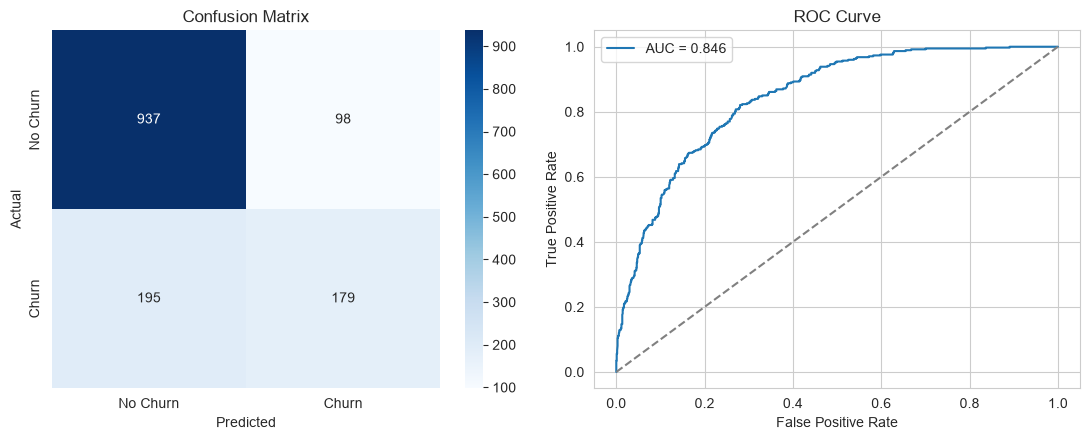

In [15]:
from sklearn.metrics import confusion_matrix, roc_curve, auc

cm = confusion_matrix(y_test, test_preds)
fpr, tpr, thresholds = roc_curve(y_test, test_probs)
roc_auc_value = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"], ax=axes[0])
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

axes[1].plot(fpr, tpr, label="AUC = " + str(round(roc_auc_value, 3)))
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

plt.tight_layout()
plt.show()

On the test set the model got precision 0.646, recall 0.479, f1 0.55 and roc-auc 0.846. So it's basically in line with what the cross-validation during tuning predicted, which is good, it means the model is not overfitting badly.

Looking at the confusion matrix, out of 374 customers who actually churned in the test set, the model caught 179 of them and missed 195. It also flagged 98 people as churn risks who did not actually churn. So right now the model catches under half of the real churners, which is not amazing, but every one of those 179 is a customer the retention team gets a chance to save that they would have otherwise lost with no warning at all.

This is exactly the precision vs recall trade-off I mentioned back in Section 2. If the business wants to catch more of the 195 churners we're currently missing, we could lower the decision threshold (instead of the default 0.5) so the model flags more people as risky. That would raise recall but also raise the number of false alarms, meaning more discounts handed out to people who were never going to leave, which costs money. Where exactly to set that threshold really depends on how much a retention offer costs versus how much one lost customer costs the company, which is more of a business decision than a purely technical one.

## Section 6: Discussion, Business Recommendations & Deployment

Now that I have a trained and tested model, let me step back and think about what this actually means for the business, not just the raw numbers.

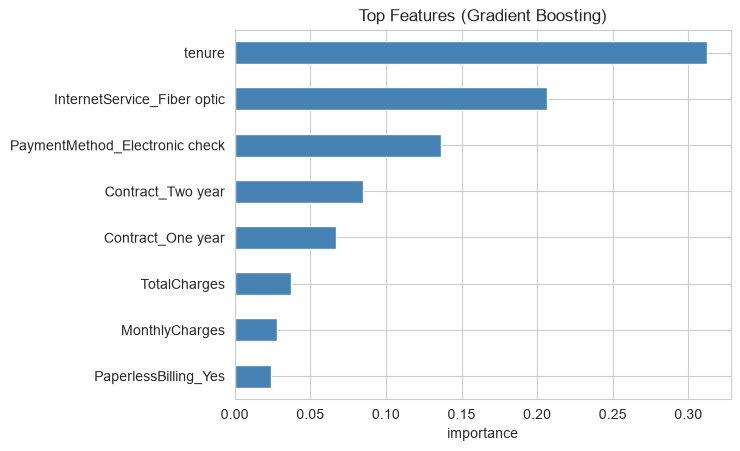

In [16]:
# check which features the model actually relies on
importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(8)

top_features.plot(kind="barh", color="steelblue")
plt.gca().invert_yaxis()
plt.title("Top Features (Gradient Boosting)")
plt.xlabel("importance")
plt.show()

By far the biggest driver is `tenure`, then having Fiber optic internet, then paying by electronic check, then being on a 1 or 2 year contract. This lines up with what I already noticed back in Section 2 with tenure and contract type, so it's reassuring that the model is picking up on real patterns and not something weird. Since it's a tree based model with a manageable number of features, I can just read off these importances directly, so I'd call this reasonably explainable, not a total black box.

Strengths and limitations: the model gets a decent ROC-AUC of 0.846, so it's fairly good at ranking who is more or less likely to churn. But recall is still under 50%, so more than half the actual churners are not being caught. I would call this a solid first version, not a finished solution. Things I would try next time with more time: testing other thresholds instead of the default 0.5, trying SMOTE or class weights to deal with the imbalance more directly, and maybe adding features like number of support calls if that data existed.

Business recommendations: since contract type and tenure matter so much, I would tell the company to focus retention effort on month-to-month customers in their first year, that is clearly the highest risk group. For customers who also have fiber optic internet or pay by electronic check, a proactive call or a discount to move them onto a longer contract seems like a reasonable first step. Rather than using a strict yes/no cutoff, I would rank customers by the model's probability score and let the retention team work down the list, starting with the highest risk customers, especially since the team probably has a limited budget for retention offers.

Deployment: I think this is ready for batch scoring rather than real time. Churn is not something that needs an instant reaction, so scoring the full customer list once a week or once a month and handing the retention team a ranked list should work fine. Before actually deploying anything I would want to check the model again on newer data every few months, since customer behaviour and pricing plans can change over time.

## References

BlastChar (n.d.) *Telco Customer Churn* [Dataset]. Kaggle. Available at: https://www.kaggle.com/datasets/blastchar/telco-customer-churn (Accessed: 14 September 2026).

Pedregosa, F. et al. (2011) 'Scikit-learn: Machine Learning in Python', *Journal of Machine Learning Research*, 12, pp. 2825–2830.